# M1~M3 — XGBoost

| 모델 | X | 변수 | 역할 |
|---|---|---|---|
| M1 | A 금융 | 18 | 베이스라인 |
| M2 | B 비금융 | 31 | 참고치 |
| M3 | A+B | 49 | 기준 모델 |

**RQ1 검증** — M3 vs M1 의 AUC 차이 = 비금융(B)의 순수 추가 기여

**입력** — `model_A_financial_final.csv` / `model_B_nonfinancial_final.csv`

**출력** — `results_M1M3.csv` / `delong_M1M3.csv` /
`importance_M3.csv` / `oof_M1M3.csv`

`oof_M1M3.csv` 는 **M4 노트북에서 RQ2 를 계산할 때 사용**하므로 반드시 저장한다.

실행 시간은 Colab 기준 약 8분.

## 0. 설정

In [ ]:
!pip install xgboost -q

import os, warnings, time, gc
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from scipy import stats
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

SRC = '/content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산'
OUT = f'{SRC}/모델링'
os.makedirs(OUT, exist_ok=True)

FILE_A = f'{SRC}/model_A_financial_final.csv'
FILE_B = f'{SRC}/model_B_nonfinancial_final.csv'
FILE_C = f'{SRC}/model_C_nonfinancial_new_final.csv'

N_FOLDS = 5           # 최종 5, 빠른 테스트 3
SAMPLE_N = None       # None=전체 30만, 빠른 테스트는 150000
RANDOM_STATE = 42
EARLY_STOP = 80
ID, TARGET = 'SK_ID_CURR', 'TARGET'

print('xgboost', xgb.__version__, '| 출력 ->', OUT)

Mounted at /content/drive
xgboost 3.3.0 | 출력 -> /content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산/모델링


## 1. 로드 & 병합

- `bool` 컬럼은 `int` 로 변환한다
- 비수치 컬럼(`AGE_BAND` 등)은 `is_numeric_dtype` 으로 자동 제외한다

In [ ]:
A = pd.read_csv(FILE_A)
B = pd.read_csv(FILE_B)

a_cols = [c for c in A.columns if c not in (ID, TARGET)]
b_cols = [c for c in B.columns if c not in (ID, TARGET)]

df = A.merge(B[[ID] + b_cols], on=ID, how='inner')
del A, B; gc.collect()

for c in df.columns:
    if df[c].dtype == bool:
        df[c] = df[c].astype(int)

drop = [c for c in df.columns
        if c not in (ID, TARGET) and not is_numeric_dtype(df[c])]
if drop:
    print(f'  비수치 컬럼 제외: {drop}')
a_cols = [c for c in a_cols if c not in drop]
b_cols = [c for c in b_cols if c not in drop]

if SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=1).reset_index(drop=True)

y = df[TARGET].values
SPW = (y == 0).sum() / (y == 1).sum()

SPECS = {'M1': a_cols, 'M2': b_cols, 'M3': a_cols + b_cols}
X_DESC = {'M1': 'A', 'M2': 'B', 'M3': 'A+B'}
grp = {**{c: 'A_금융' for c in a_cols}, **{c: 'B_전통비금융' for c in b_cols}}

print(f'  {len(df):,}행, 부도율 {y.mean():.2%}')
print(f'  A(금융) {len(a_cols)} / B(전통비금융) {len(b_cols)}')
for k, v in SPECS.items():
    print(f'  {k} ({X_DESC[k]}): {len(v):3d}개')
print(f'  scale_pos_weight = {SPW:.2f}')

folds = list(StratifiedKFold(N_FOLDS, shuffle=True,
                             random_state=RANDOM_STATE).split(df, y))

  비수치 컬럼 제외: ['AGE_BAND']
  307,511행, 부도율 8.07%
  A(금융) 18 / B(전통비금융) 31
  M1 (A):  18개
  M2 (B):  31개
  M3 (A+B):  49개
  scale_pos_weight = 11.39


## 2. 하이퍼파라미터

| 설정 | 값 | 이유 |
|---|---|---|
| `n_estimators` | 1000 | early stopping 이 실제 트리 수를 정한다 |
| `learning_rate` | 0.02 | 낮게 두고 트리를 많이 쌓는 방식 |
| `max_depth` | 5 | 30만 행 대비 과적합을 억제하는 수준 |
| `colsample_bytree` | 0.8 | 변수 간 상관이 높아 열 샘플링으로 완화 |
| `subsample` | 0.9 | 행 샘플링으로 분산 축소 |
| `min_child_weight` | 100 | 리프 최소 표본. 소수 범주 과적합 방지 |
| `reg_lambda` | 1.0 | L2 정규화 |
| `scale_pos_weight` | 11.39 | 클래스 불균형 보정 |
| **`importance_type`** | **`total_gain`** | **중요도 집계 방식** |

**불균형 보정** — 부도율 8.07% 로 1:11.4 불균형이다.
보정 없이 학습하면 다수 클래스에 치우친다.

**`importance_type='total_gain'` 을 지정하는 이유**

XGBoost 의 기본값은 `'gain'` 인데, 이는 **분할당 평균 gain** 이다.
가끔 쓰이지만 쓸 때 효과가 큰 이진 더미를 과대평가하고,
수백 번 분할되는 연속형은 평균이 희석되어 과소평가된다.

`'total_gain'` 은 총합이라 실제 기여를 그대로 반영하며,
다른 라이브러리와 대응 관계가 성립한다.

| 개념 | XGBoost | LightGBM |
|---|---|---|
| 분할 횟수 | `weight` | `split` (기본) |
| **총 gain** | **`total_gain`** | **`gain`** |
| 평균 gain | `gain` (기본) | 없음 |

`importance_type` 은 학습이 끝난 뒤 중요도를 집계하는 방식만 정한다.
**모델과 예측값, AUC 는 달라지지 않는다.**

In [ ]:
TREE_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    colsample_bytree=0.8,
    subsample=0.9,
    reg_lambda=1.0,
    min_child_weight=100,
    scale_pos_weight=SPW,
    tree_method='hist',
    eval_metric='auc',
    early_stopping_rounds=EARLY_STOP,
    importance_type='total_gain',   # 기본값 'gain'(평균) 이 아닌 총합
    n_jobs=-1,
    verbosity=0,
    random_state=RANDOM_STATE,
)
TREE_PARAMS

{'n_estimators': 1000,
 'learning_rate': 0.02,
 'max_depth': 5,
 'colsample_bytree': 0.8,
 'subsample': 0.9,
 'reg_lambda': 1.0,
 'min_child_weight': 100,
 'scale_pos_weight': np.float64(11.387150050352467),
 'tree_method': 'hist',
 'eval_metric': 'auc',
 'early_stopping_rounds': 80,
 'importance_type': 'total_gain',
 'n_jobs': -1,
 'verbosity': 0,
 'random_state': 42}

## 3. 교차검증

**검증 fold 누수 차단** — `eval_set` 에 검증 fold 를 그대로 넣으면
트리 개수를 그 fold 를 보고 정하게 되어 OOF 예측이 낙관적으로 나온다.
train 을 다시 90:10 으로 쪼개 early stopping 전용 셋을 만든다.

In [ ]:
def cv_tree(cols):
    X = df[cols].replace([np.inf, -np.inf], np.nan).astype('float32')
    oof = np.zeros(len(y))
    iters, imps = [], []

    for k, (tr, va) in enumerate(folds, 1):
        itr, ies = train_test_split(tr, test_size=0.1,
                                    random_state=RANDOM_STATE + k,
                                    stratify=y[tr])
        mdl = xgb.XGBClassifier(**TREE_PARAMS)
        mdl.fit(X.iloc[itr], y[itr],
                eval_set=[(X.iloc[ies], y[ies])], verbose=False)

        iters.append(mdl.best_iteration)
        oof[va] = mdl.predict_proba(X.iloc[va])[:, 1]
        imps.append(pd.Series(mdl.feature_importances_, index=cols))
        del mdl; gc.collect()

    return oof, roc_auc_score(y, oof), int(np.mean(iters)), \
           pd.concat(imps, axis=1).mean(axis=1)

## 4. DeLong 검정

같은 표본에서 나온 두 AUC 를 비교하는 검정.
상관된 AUC 를 다루므로 일반 t검정을 쓰면 안 된다.

In [ ]:
def _mr(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1; i = j
    o = np.empty(N); o[J] = T
    return o


def delong(y, s1, s2):
    """반환: (ΔAUC = AUC(s1)-AUC(s2), p_value)"""
    y = np.asarray(y); od = (-y).argsort(kind='mergesort'); mp = int(y.sum())
    p = np.vstack([np.asarray(s1)[od], np.asarray(s2)[od]]); n = p.shape[1] - mp
    tx = np.vstack([_mr(p[r, :mp]) for r in range(2)])
    ty = np.vstack([_mr(p[r, mp:]) for r in range(2)])
    tz = np.vstack([_mr(p[r, :]) for r in range(2)])
    a = tz[:, :mp].sum(1) / mp / n - (mp + 1) / 2 / n
    cov = np.cov((tz[:, :mp] - tx) / n) / mp + np.cov(1 - (tz[:, mp:] - ty) / mp) / n
    l = np.array([[1, -1]])
    v = float(np.asarray(l @ np.atleast_2d(cov) @ l.T).ravel()[0])
    dl_ = float(a[0] - a[1])
    if v <= 0:
        return dl_, (1.0 if abs(dl_) < 1e-12 else np.nan)
    z = dl_ / np.sqrt(v)
    return dl_, float(2 * (1 - stats.norm.cdf(abs(z))))

## 5. 학습 — M1, M2, M3

가장 오래 걸리는 셀이다.

In [ ]:
oofs, rows, imps = {}, [], {}
for name, cols in SPECS.items():
    t0 = time.time()
    o, auc_, it, imp_ = cv_tree(cols)
    oofs[name], imps[name] = o, imp_
    rows.append({'모델': name, 'X구성': X_DESC[name], '변수수': len(cols),
                 'AUC': round(auc_, 5), '평균트리': it,
                 '초': round(time.time() - t0)})
    print(f'  {name} ({X_DESC[name]:4s}) n={len(cols):3d} AUC={auc_:.5f} '
          f'trees={it} ({time.time()-t0:.0f}s)', flush=True)

results = pd.DataFrame(rows)
auc = dict(zip(results['모델'], results['AUC']))
display(results.style.hide(axis='index')
        .background_gradient(subset=['AUC'], cmap='Blues')
        .format({'AUC': '{:.5f}'}))

  M1 (A   ) n= 18 AUC=0.69786 trees=925 (100s)
  M2 (B   ) n= 31 AUC=0.62528 trees=320 (46s)
  M3 (A+B ) n= 49 AUC=0.71083 trees=983 (150s)


모델,X구성,변수수,AUC,평균트리,초
M1,A,18,0.69786,925,100
M2,B,31,0.62528,320,46
M3,A+B,49,0.71083,983,150


## 6. RQ1 검정

`H0 : AUC(M3) = AUC(M1)`

In [ ]:
dl_rows = []
for tag, a_, b_ in [('RQ1 (M3-M1) 비금융 추가기여', 'M3', 'M1'),
                    ('(참고) M3-M2', 'M3', 'M2'),
                    ('(참고) M2-M1', 'M2', 'M1')]:
    d, p = delong(y, oofs[a_], oofs[b_])
    dl_rows.append({'비교': tag, 'ΔAUC': round(d, 5), 'DeLong_p': p,
                    '통계유의': '유의' if p < 0.05 else '비유의',
                    '실무유의': '충족' if d >= 0.01 else '미달'})

delong_df = pd.DataFrame(dl_rows)
display(delong_df.style.hide(axis='index')
        .format({'ΔAUC': '{:+.5f}', 'DeLong_p': '{:.3e}'}))

r1 = delong_df.iloc[0]
print('=' * 60)
print(f'M1 (A)   n={len(SPECS["M1"]):3d}  AUC={auc["M1"]:.5f}')
print(f'M2 (B)   n={len(SPECS["M2"]):3d}  AUC={auc["M2"]:.5f}')
print(f'M3 (A+B) n={len(SPECS["M3"]):3d}  AUC={auc["M3"]:.5f}')
print('-' * 60)
print(f'RQ1: 비금융(B)의 추가 기여   ΔAUC={r1["ΔAUC"]:+.5f}  '
      f'p={r1["DeLong_p"]:.3e}  {r1["통계유의"]} / 실무 {r1["실무유의"]}')
print('=' * 60)

비교,ΔAUC,DeLong_p,통계유의,실무유의
RQ1 (M3-M1) 비금융 추가기여,+0.01297,0.000e+00,유의,충족
(참고) M3-M2,+0.08554,0.000e+00,유의,충족
(참고) M2-M1,-0.07257,0.000e+00,유의,미달


M1 (A)   n= 18  AUC=0.69786
M2 (B)   n= 31  AUC=0.62528
M3 (A+B) n= 49  AUC=0.71083
------------------------------------------------------------
RQ1: 비금융(B)의 추가 기여   ΔAUC=+0.01297  p=0.000e+00  유의 / 실무 충족


## 7. M3 변수중요도

`total_gain` 기준. 전체 합이 1이 되도록 정규화되어 있다.
**크기만 있고 부호가 없다.**

In [ ]:
imp3 = imps['M3'].sort_values(ascending=False)
imp_df = pd.DataFrame({'변수': imp3.index, '군': [grp[c] for c in imp3.index],
                       '중요도': imp3.values})
imp_df.insert(0, '순위', range(1, len(imp_df) + 1))
imp_df['비중(%)'] = (imp_df['중요도'] / imp_df['중요도'].sum() * 100).round(2)

g = imp_df.groupby('군')['중요도'].agg(['sum', 'count'])
g.columns = ['중요도합', '변수수']
g['변수당'] = (g['중요도합'] / g['변수수']).round(4)
g['비중(%)'] = (g['중요도합'] / imp_df['중요도'].sum() * 100).round(1)

print('■ 군별 중요도')
display(g)
print('■ M3 변수중요도 상위 20')
display(imp_df.head(20).style.hide(axis='index')
        .background_gradient(subset=['중요도'], cmap='Oranges')
        .format({'중요도': '{:.4f}', '비중(%)': '{:.2f}'}))

■ 군별 중요도


,중요도합,변수수,변수당,비중(%)
군,,,,
A_금융,0.721029,18,0.0401,72.099998
B_전통비금융,0.278971,31,0.0090,27.900000


■ M3 변수중요도 상위 20


순위,변수,군,중요도,비중(%)
1,ANNUITY_TO_CREDIT,A_금융,0.2146,21.46
2,AGE,B_전통비금융,0.0967,9.67
3,LTV_GOODS,A_금융,0.0934,9.34
4,BUREAU_DEBT_RATIO,A_금융,0.0865,8.65
5,YEARS_EMPLOYED,B_전통비금융,0.0857,8.57
6,BUREAU_ACTIVE_LOAN_COUNT,A_금융,0.0576,5.76
7,BUREAU_LOAN_COUNT,A_금융,0.0467,4.67
8,AMT_GOODS_PRICE,A_금융,0.0447,4.47
9,AMT_ANNUITY,A_금융,0.0388,3.88
10,CREDIT_TO_INCOME,A_금융,0.0335,3.35


## 8. 시각화

축 라벨은 한글 폰트 설치 없이 렌더되도록 영문으로 둔다.

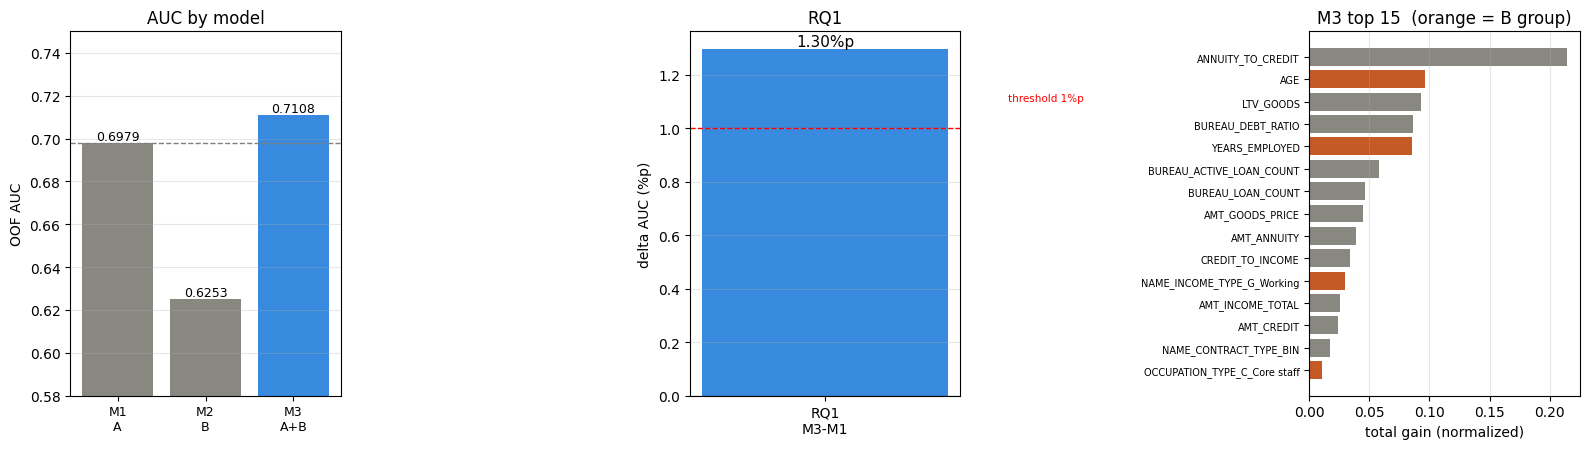

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
order = ['M1', 'M2', 'M3']

b = ax[0].bar(order, [auc[k] for k in order],
              color=['#888780', '#888780', '#378ADD'])
ax[0].bar_label(b, fmt='%.4f', fontsize=9)
ax[0].axhline(auc['M1'], ls='--', c='gray', lw=1)
ax[0].set_ylim(0.58, 0.75); ax[0].set_ylabel('OOF AUC')
ax[0].set_xticks(range(3))
ax[0].set_xticklabels([f'{k}\n{X_DESC[k]}' for k in order], fontsize=9)
ax[0].set_title('AUC by model'); ax[0].grid(axis='y', alpha=.3)

d1 = delong_df.iloc[0]['ΔAUC'] * 100
b = ax[1].bar(['RQ1\nM3-M1'], [d1], color='#378ADD', width=.4)
ax[1].bar_label(b, fmt='%.2f%%p', fontsize=11)
ax[1].axhline(1, ls='--', c='red', lw=1)
ax[1].axhline(0, c='black', lw=.8)
ax[1].text(0.42, 1.1, 'threshold 1%p', color='red', fontsize=7.5, ha='right')
ax[1].set_ylabel('delta AUC (%p)'); ax[1].set_title('RQ1')
ax[1].grid(axis='y', alpha=.3)

t15 = imp_df.head(15).iloc[::-1]
cmap = {'A_금융': '#888780', 'B_전통비금융': '#C45A26'}
ax[2].barh(range(len(t15)), t15['중요도'], color=[cmap[v] for v in t15['군']])
ax[2].set_yticks(range(len(t15)))
ax[2].set_yticklabels([v[:32] for v in t15['변수']], fontsize=7)
ax[2].set_xlabel('total gain (normalized)')
ax[2].set_title('M3 top 15  (orange = B group)')
ax[2].grid(axis='x', alpha=.3)

plt.tight_layout(); plt.show()

## 9. CSV 저장

**`oof_M1M3.csv` 는 M4 노트북에서 RQ2 계산에 사용하므로 반드시 저장한다.**

In [ ]:
results.to_csv(f'{OUT}/results_M1M3.csv', index=False, encoding='utf-8-sig')
delong_df.to_csv(f'{OUT}/delong_M1M3.csv', index=False, encoding='utf-8-sig')
imp_df.to_csv(f'{OUT}/importance_M3.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({ID: df[ID].values, TARGET: y,
              **{f'oof_{k}': v for k, v in oofs.items()}}) \
  .to_csv(f'{OUT}/oof_M1M3.csv', index=False)

print(f'저장 완료 -> {OUT}')
for f_, d_ in [('results_M1M3.csv', results), ('delong_M1M3.csv', delong_df),
               ('importance_M3.csv', imp_df)]:
    print(f'  {f_:24s} {d_.shape[0]:2d}행 x {d_.shape[1]}열')
print(f'  {"oof_M1M3.csv":24s} {len(df):,}행   <- M4 노트북에서 사용')

저장 완료 -> /content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산/모델링
  results_M1M3.csv          3행 x 6열
  delong_M1M3.csv           3행 x 5열
  importance_M3.csv        49행 x 5열
  oof_M1M3.csv             307,511행   <- M4 노트북에서 사용


In [ ]:
# M1, M2 변수중요도 저장
for k in ['M1', 'M2']:
    s = imps[k].sort_values(ascending=False)
    d = pd.DataFrame({'변수': s.index,
                      '군': [grp[c] for c in s.index],
                      '중요도': s.values})
    d.insert(0, '순위', range(1, len(d) + 1))
    d['비중(%)'] = (d['중요도'] / d['중요도'].sum() * 100).round(2)
    d.to_csv(f'{OUT}/importance_{k}.csv', index=False, encoding='utf-8-sig')
    print(f'  importance_{k}.csv  {len(d)}행')
    display(d.head(10).style.hide(axis='index')
            .format({'중요도': '{:.4f}', '비중(%)': '{:.2f}'}))

  importance_M1.csv  18행


순위,변수,군,중요도,비중(%)
1,ANNUITY_TO_CREDIT,A_금융,0.3372,33.72
2,LTV_GOODS,A_금융,0.1199,11.99
3,BUREAU_DEBT_RATIO,A_금융,0.1147,11.47
4,BUREAU_LOAN_COUNT,A_금융,0.0660,6.60
5,BUREAU_ACTIVE_LOAN_COUNT,A_금융,0.0601,6.01
6,AMT_GOODS_PRICE,A_금융,0.0598,5.98
7,AMT_ANNUITY,A_금융,0.0556,5.56
8,CREDIT_TO_INCOME,A_금융,0.0439,4.39
9,AMT_CREDIT,A_금융,0.0346,3.46
10,AMT_INCOME_TOTAL,A_금융,0.0310,3.10


  importance_M2.csv  31행


순위,변수,군,중요도,비중(%)
1,AGE,B_전통비금융,0.3257,32.57
2,YEARS_EMPLOYED,B_전통비금융,0.3005,30.05
3,NAME_INCOME_TYPE_G_Working,B_전통비금융,0.0967,9.67
4,OCCUPATION_TYPE_C_Accountants,B_전통비금융,0.0425,4.25
5,OCCUPATION_TYPE_C_Core staff,B_전통비금융,0.0377,3.77
6,OCCUPATION_TYPE_C_Managers,B_전통비금융,0.0297,2.97
7,OCCUPATION_TYPE_C_High skill tech staff,B_전통비금융,0.0239,2.39
8,OCCUPATION_TYPE_C_Drivers,B_전통비금융,0.0207,2.07
9,OCCUPATION_TYPE_C_Unknown,B_전통비금융,0.0169,1.69
10,NAME_INCOME_TYPE_G_Commercial associate,B_전통비금융,0.0164,1.64


### 다음 단계

`xgb_M4.ipynb` 를 실행하면 C군을 추가한 M4 와 RQ2 검정 결과가 나온다.
이 노트북의 `oof_M1M3.csv` 를 자동으로 불러 쓰므로 먼저 실행해야 한다.